<a href="https://colab.research.google.com/github/Saiakashaya/DATA_SCIENCE/blob/main/ml_linear%20regression_mu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download patelris/crop-yield-prediction-dataset

Dataset URL: https://www.kaggle.com/datasets/patelris/crop-yield-prediction-dataset
License(s): world-bank
100% 959k/959k [00:00<00:00, 129MB/s]



In [ ]:
ls-ltr /content

total 964
-rw-r--r-- 1 root root 981807 May 18 12:15 crop-yield-prediction-dataset.zip
drwxr-xr-x 1 root root   4096 Jun  4 13:32 sample_data/


In [ ]:
!unzip crop-yield-prediction-dataset.zip

Archive:  crop-yield-prediction-dataset.zip
  inflating: pesticides.csv          
  inflating: rainfall.csv            
  inflating: temp.csv                
  inflating: yield.csv               
  inflating: yield_df.csv            


In [ ]:
!chmod 777  yield_df.csv

In [ ]:
import pandas as pd
df=pd.read_csv('yield_df.csv')
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [37]:
crop=df['Item']
crop

,Item
0,Maize
1,Potatoes
2,"Rice, paddy"
3,Sorghum
4,Soybeans
...,...
28237,"Rice, paddy"
28238,Sorghum
28239,Soybeans
28240,Sweet potatoes


In [38]:
crop_yield=df['hg/ha_yield']
crop_yield

,hg/ha_yield
0,36613
1,66667
2,23333
3,12500
4,7000
...,...
28237,22581
28238,3066
28239,13142
28240,22222


In [39]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [40]:
import numpy as np
x=np.array(crop).reshape(-1,1)
y=np.array(crop_yield).reshape(-1,1)

In [41]:
x

array([['Maize'],
       ['Potatoes'],
       ['Rice, paddy'],
       ...,
       ['Soybeans'],
       ['Sweet potatoes'],
       ['Wheat']], dtype=object)

In [42]:
y

array([[36613],
       [66667],
       [23333],
       ...,
       [13142],
       [22222],
       [22888]])

In [43]:
import pandas as pd
# One-hot encode the 'crop' column (which is df['Item'])
x_encoded = pd.get_dummies(crop)

# Fit the model with the one-hot encoded features
model.fit(x_encoded,y)

LinearRegression()

In [45]:
import pandas as pd
import numpy as np

new_crop_input = input("Enter your crop (e.g., Maize, Potatoes): ")
new_crop_name = new_crop_input.strip().title()
trained_crop_columns = x_encoded.columns

new_crop_one_hot_dict = {col: 0 for col in trained_crop_columns}

if new_crop_name in new_crop_one_hot_dict:
    new_crop_one_hot_dict[new_crop_name] = 1

    # Convert the dictionary to a DataFrame, ensuring column order matches trained data
    new_data_encoded = pd.DataFrame([new_crop_one_hot_dict], columns=trained_crop_columns)

    y_answer = model.predict(new_data_encoded)
    print(f"Your predicted crop yield for {new_crop_name} is: {y_answer[0][0]:.2f} hg/ha")
elif new_crop_name:
    print(f"Error: Crop '{new_crop_name}' not found in the trained data.")
    print(f"Please choose from: {', '.join(trained_crop_columns)}")
else:
    print("No crop name entered.")

Enter your crop (e.g., Maize, Potatoes): Maize
Your predicted crop yield for Maize is: 36310.07 hg/ha


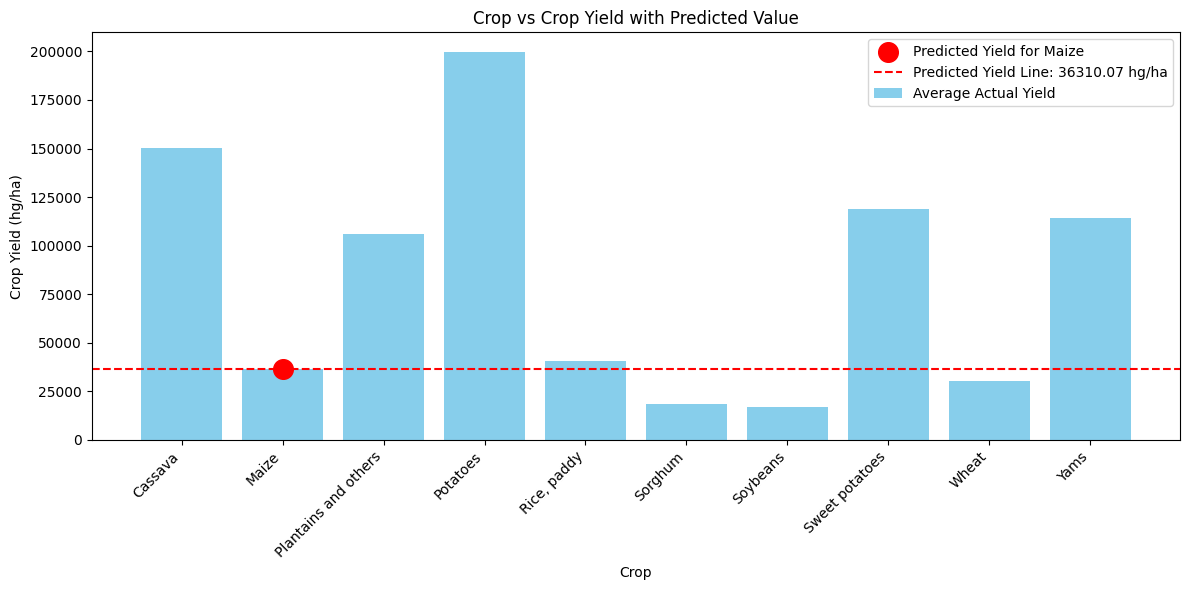

In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

crop_data_for_plotting = pd.DataFrame({'Item': crop, 'hg/ha_yield': crop_yield})
average_yield_per_crop = crop_data_for_plotting.groupby('Item')['hg/ha_yield'].mean().reset_index()

average_yield_per_crop = average_yield_per_crop.sort_values('Item')
crop_labels = average_yield_per_crop['Item']
avg_yields = average_yield_per_crop['hg/ha_yield']

# Create the bar plot for actual average yields
plt.figure(figsize=(12, 6))
plt.bar(crop_labels, avg_yields, color='skyblue', label='Average Actual Yield')

# Plot the predicted yield for the new crop
# new_crop_name and y_answer are available from the previous cell execution
try:
    if new_crop_name in crop_labels.values:
        # Get the index of the new crop name in the sorted labels for positioning
        x_pos = list(crop_labels).index(new_crop_name) # Convert to list for index lookup
        plt.scatter(x_pos, y_answer[0][0], color='red', s=200, zorder=5, label=f'Predicted Yield for {new_crop_name}')
        plt.axhline(y=y_answer[0][0], color='red', linestyle='--', label=f'Predicted Yield Line: {y_answer[0][0]:.2f} hg/ha')
    else:
        print(f"Warning: '{new_crop_name}' not found in original crop data for direct comparison in bar chart. Skipping prediction plot.")
except NameError:
    print("Prediction variables (new_crop_name, y_answer) not defined. Skipping prediction plot.")

plt.xlabel("Crop")
plt.ylabel("Crop Yield (hg/ha)")
plt.title("Crop vs Crop Yield with Predicted Value")
plt.xticks(rotation=45, ha='right') # Rotate labels for readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.legend()
plt.show()